Aap sab ko *Regression Assignment* diya ja raha hai. Is assignment ka objective data preprocessing aur regression model develop karna hai.

### Assignment Requirements

* Dataset ko properly analyze karein.
* Missing values ko handle karein (agar available hon).
* Required encoding perform karein (agar zarurat ho).
* Feature Scaling apply karein (agar required ho).
* Different Regression Models apply karein aur unki performance compare karein.
* MAE, MSE, RMSE aur R² Score calculate karein.
* Best performing model select karein.
* Hyperparameter Tuning karke model ki performance improve karne ki koshish karein.
* Model ki accuracy/performance ko maximum possible level tak optimize karein.
* Har step ki proper explanation aur code comments bhi include karein.


In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('regression-housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Basic info about the dataset - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
# Summary statistics for numeric columns
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Check for missing values
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# total_bedrooms has 207 missing values, small % of the dataset (20640 rows)
# Drop the rows with missing values
df.dropna(inplace=True)
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Check for negative values in numeric columns
# (longitude is expected to be negative for California, that is normal, not an error)
(df.select_dtypes(include='number') < 0).sum()

longitude             20433
latitude                  0
housing_median_age        0
total_rooms               0
total_bedrooms            0
population                0
households                0
median_income             0
median_house_value        0
dtype: int64

In [9]:
# Check the categories in ocean_proximity column
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [10]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

### EDA - Target Variable (median_house_value)

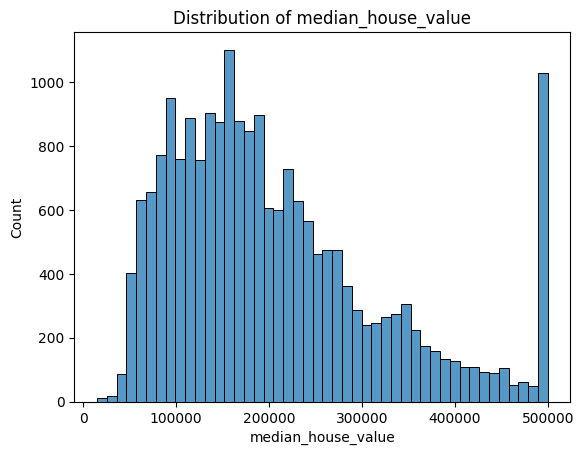

In [11]:
sns.histplot(df['median_house_value'])
plt.title('Distribution of median_house_value')
plt.show()

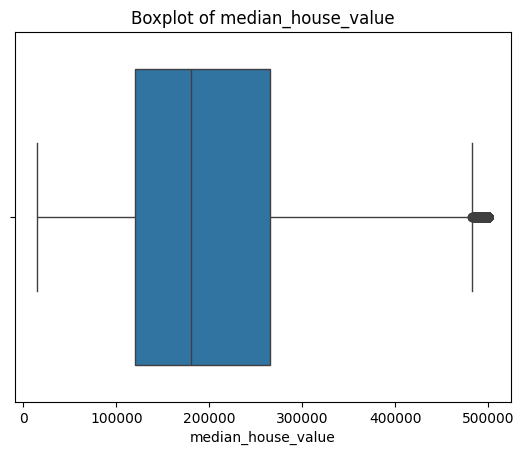

In [12]:
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot of median_house_value')
plt.show()

In [13]:
df['median_house_value'].describe()

count     20433.000000
mean     206864.413155
std      115435.667099
min       14999.000000
25%      119500.000000
50%      179700.000000
75%      264700.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [14]:
# Around 500001 looks like a capped value (a lot of houses stuck at exact same max price)
# This is a known issue with this dataset - houses above 500000 got capped at 500001
(df['median_house_value'] == 500001).sum()

np.int64(958)

In [15]:
# Drop the capped rows since they do not reflect the real house value
df = df[df['median_house_value'] != 500001]
df.shape

(19475, 10)

### Encoding
`ocean_proximity` is a categorical (text) column, so it needs to be encoded before using it in a model.
One-Hot Encoding is used here since the categories have no natural order.

In [16]:
# One Hot Encode the ocean_proximity column
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[['ocean_proximity']])

encoded_categories = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['ocean_proximity'])).astype(int)
encoded_categories.head()

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [17]:
# Get numeric columns only, reset index so it lines up with encoded_categories
numbered_data = df.select_dtypes('number').reset_index(drop=True)

# Combine numeric columns with the encoded categorical columns
final_data = pd.concat([numbered_data, encoded_categories], axis=1)
final_data.isna().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

### Correlation

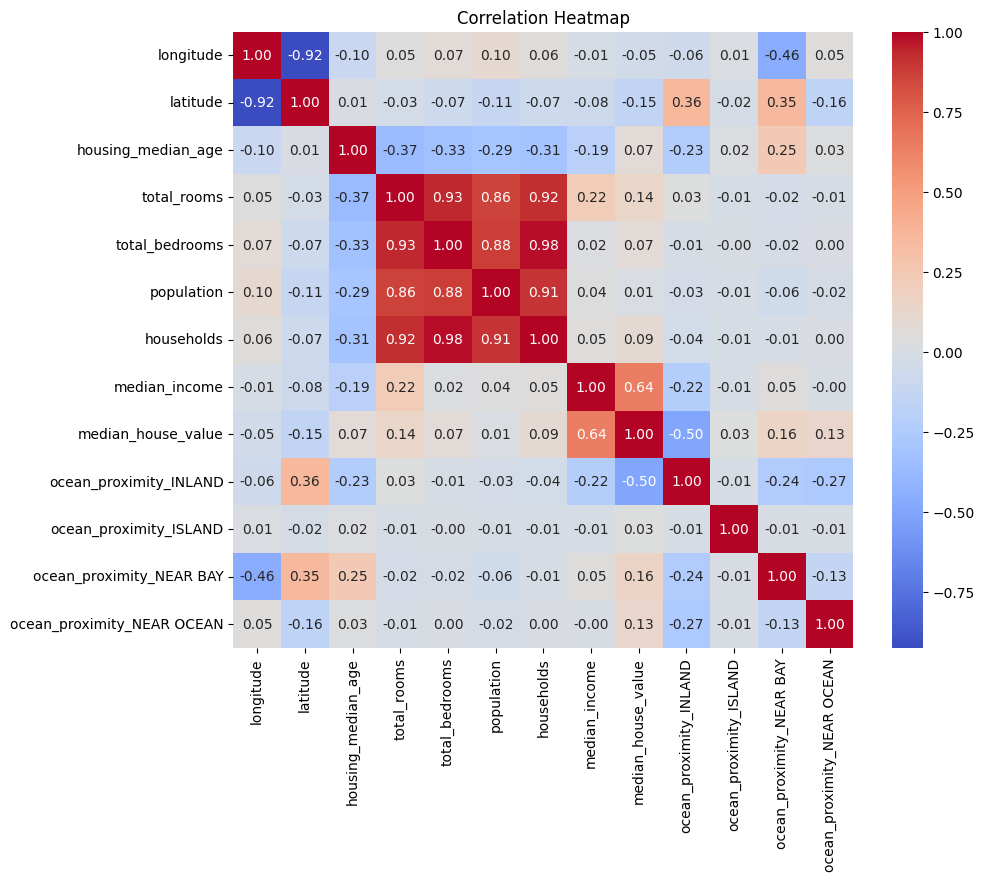

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(final_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Feature and Target Selection

In [19]:
# Target: what we are predicting
y = final_data['median_house_value']

# Features: everything else
X = final_data.drop(columns=['median_house_value'])

print(X.shape, y.shape)

(19475, 12) (19475,)


### Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((15580, 12), (3895, 12))

### Feature Scaling
Scaling makes sure all numeric columns are on a similar range, which helps some models perform better.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Multiple Regression Models and Compare

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dictionary of models we want to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f'{name} -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}')
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

Linear Regression -> MAE: 44712.91, MSE: 3706535595.03, RMSE: 60881.32, R2: 0.6173
Ridge Regression -> MAE: 44711.90, MSE: 3706426521.62, RMSE: 60880.43, R2: 0.6173


Lasso Regression -> MAE: 44712.56, MSE: 3706493514.06, RMSE: 60880.98, R2: 0.6173
Decision Tree -> MAE: 41847.75, MSE: 3916730682.21, RMSE: 62583.79, R2: 0.5956


Random Forest -> MAE: 30047.55, MSE: 1975960721.11, RMSE: 44451.78, R2: 0.7960


In [23]:
# Put results in a table and sort by R2 score, best model on top
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Model,MAE,MSE,RMSE,R2
4,Random Forest,30047.554228,1.975961e+09,44451.779729,0.795979
1,Ridge Regression,44711.898661,3.706427e+09,60880.428067,0.617305
2,Lasso Regression,44712.556345,3.706494e+09,60880.978261,0.617298
0,Linear Regression,44712.907291,3.706536e+09,60881.323861,0.617294
3,Decision Tree,41847.753787,3.916731e+09,62583.789293,0.595591


### Best Model
Based on the table above, Random Forest performs the best (highest R2, lowest errors). We will now tune it to try to improve it further.

### Hyperparameter Tuning (Random Forest)

In [24]:
from sklearn.model_selection import GridSearchCV

# A small grid of values to try, keeping it simple
param_grid = {
    'n_estimators': [50],
    'max_depth': [15, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=2,
    scoring='r2'
)

grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)

Best parameters: {'max_depth': None, 'n_estimators': 50}


In [25]:
# Evaluate the tuned model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f'Tuned Random Forest -> MAE: {mae_best:.2f}, MSE: {mse_best:.2f}, RMSE: {rmse_best:.2f}, R2: {r2_best:.4f}')

Tuned Random Forest -> MAE: 30047.55, MSE: 1975960721.11, RMSE: 44451.78, R2: 0.7960


### Prediction Results

In [26]:
# Compare actual vs predicted values on the test set
final_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best})
final_results.head(10)

,Actual,Predicted
14142,96200.0,101324.0
13854,178700.0,192166.0
2308,60600.0,75642.0
11123,191900.0,203230.0
2830,51000.0,53934.0
12644,160400.0,182252.0
2300,88900.0,88112.0
6562,147600.0,163936.0
11527,97800.0,94570.0
3461,232900.0,221318.0
